# 10 · Prompt Chaining (with a gate) — *extra pattern*

**Idea:** Split one hard prompt into a **pipeline** of easy prompts. Each step's output feeds the next.
Add a **gate** (a cheap check) between steps to stop early or route around a bad result.

```
START -> outline -> gate --(ok)--> write -> polish -> END
              ^        |
              +--(bad)-+   (retry the outline once)
```
Simplest pattern in the book; often the most reliable.

In [1]:
# --- Model setup -------------------------------------------------------------
# 1) Ollama must be running   ->  `ollama serve`  (the desktop app does this for you)
# 2) Pull the models once     ->  `ollama pull llama3.1`  and  `ollama pull qwen3:0.6b`
from langchain_ollama import ChatOllama

# llama3.1 (8B): our main "brain" - good at tool calling & structured output.
llm = ChatOllama(model="llama3.1", temperature=0)

# qwen3:0.6b: a tiny, very fast model - great for cheap jobs (classify, summarise, route).
# reasoning=False hides qwen3's <think> block so `.content` is just the answer.
small_llm = ChatOllama(model="qwen3:0.6b", temperature=0, reasoning=False)

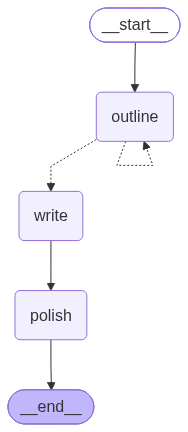

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    topic: str
    outline: str
    article: str
    final: str
    tries: int

def outline(state: State):
    o = llm.invoke(f"Write a 3-bullet outline for a short blog post about: {state['topic']}").content
    return {"outline": o, "tries": state.get("tries", 0) + 1}

def gate(state: State):
    """Cheap programmatic/LLM check. Here: the tiny model must say YES/NO to 'is it exactly 3 bullets?'"""
    verdict = small_llm.invoke(
        f"Does the text below contain exactly 3 bullet points? Answer only YES or NO.\n\n{state['outline']}"
    ).content.strip().upper()
    print("🚦 gate says:", verdict)
    return "write" if verdict.startswith("YES") or state["tries"] >= 2 else "outline"   # retry once, then move on

def write(state: State):
    return {"article": llm.invoke(f"Write a 100-word blog post following this outline:\n{state['outline']}").content}

def polish(state: State):
    return {"final": llm.invoke(f"Fix grammar and make the tone friendly. Return only the text:\n{state['article']}").content}

builder = StateGraph(State)
for name, fn in [("outline", outline), ("write", write), ("polish", polish)]:
    builder.add_node(name, fn)
builder.add_edge(START, "outline")
builder.add_conditional_edges("outline", gate, ["write", "outline"])   # gate function = the router
builder.add_edge("write", "polish")
builder.add_edge("polish", END)
graph = builder.compile()
from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
out = graph.invoke({"topic": "why sleep matters for learning"})
print("OUTLINE:\n", out["outline"], "\n\nFINAL:\n", out["final"])

🚦 gate says: YES.
OUTLINE:
 Here is a 3-bullet outline for a short blog post on why sleep matters for learning:

• **Sleep helps consolidate memories**: During sleep, the brain processes and consolidates new information and experiences, transferring them from short-term to long-term memory. This process is essential for learning and retaining new skills and knowledge.

• **Sleep improves cognitive function**: Sleep deprivation can impair attention, concentration, and problem-solving skills, making it harder to learn and absorb new information. On the other hand, getting enough sleep can enhance cognitive function, leading to better academic performance and learning outcomes.

• **Sleep supports emotional regulation and motivation**: Adequate sleep helps regulate emotions and motivation, which are critical for learning and academic success. When well-rested, students are more likely to be motivated, engaged, and resilient in the face of challenges, leading to better learning outcomes. 
